In [1]:
using Unitful 
using Plots
using Measures

gr()

Plots.GRBackend()

In [2]:
using Plots

## funziona corretta

In [3]:
min_pot =  [0.9986997, 0.9978069, 0.9986706, 1.0009229, 0.9994534, 0.99822, 0.9980831, 0.998217, 0.99594384  ,0.99681985,  0.99802446, 0.99784315,  0.9977653,  0.9981247, 0.99690855]
grid_size = ["default",0.5u"mm", 0.45u"mm", 0.4u"mm", 0.35u"mm", 0.3u"mm", 0.25u"mm", 0.2u"mm", 0.15u"mm",  0.1u"mm", 0.05u"mm", 0.035u"mm", 0.03u"mm", 0.02u"mm",  0.01u"mm"]

15-element Vector{Any}:
  "default"
 0.5 mm
 0.45 mm
 0.4 mm
 0.35 mm
 0.3 mm
 0.25 mm
 0.2 mm
 0.15 mm
 0.1 mm
 0.05 mm
 0.035 mm
 0.03 mm
 0.02 mm
 0.01 mm

In [4]:
grod_wrong = ["0.02 mm"]
min_pot_wrong = [0.69480747]

1-element Vector{Float64}:
 0.69480747

In [5]:
using Statistics
r = min_pot ./ 1  # residui normlaizzati

res = min_pot .- 1              # residui centrati a 0
σ = std(res)                    # deviazione standard
res_σ = res ./ σ                # residui normalizzati in unità di sigma
var_pct = 100 .* (min_pot .- 1)

15-element Vector{Float64}:
 -0.1300300000000032
 -0.2193099999999948
 -0.1329400000000036
  0.09228999999999488
 -0.05465999999999527
 -0.17800000000000038
 -0.19168999999999992
 -0.1782999999999979
 -0.40561599999999753
 -0.3180150000000048
 -0.19755399999999979
 -0.2156849999999988
 -0.2234700000000034
 -0.18753000000000242
 -0.30914499999999956

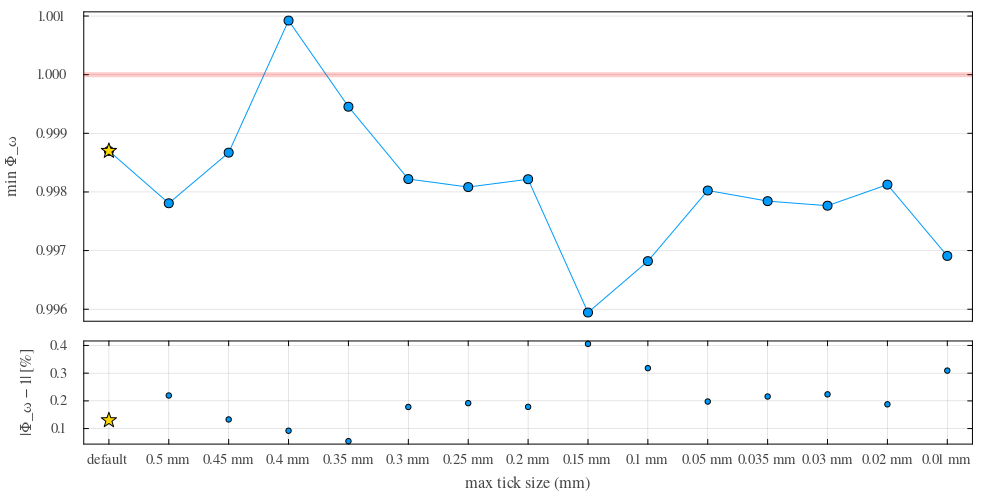

In [6]:
using Plots
using Colors

# Impostazioni "da paper"
default(
    fontfamily = "Times",
    guidefontsize = 10,
    tickfontsize = 9,
    legendfontsize = 9,
    titlefontsize = 10,
    lw = 1,
    ms = 5
)

x = 1:length(grid_size)
labels = string.(grid_size)



# Plot superiore
p1 = plot(
    x, min_pot;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    lw = 1,
    ylabel = "min Φ_ω",
    xticks = false,
    legend = false,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

hline!([1.0], linecolor = :red, lw =5 , alpha = 0.2, label = "Φ_ω = 1")
plot!( [x[1]], [min_pot[1]], seriestype = :scatter, marker = :star, markersize = 8, markercolor = :gold, )
# Plot inferiore
p2 = scatter(
    x,
    abs.(var_pct),
    ylabel = "|Φ_ω − 1| [%]",
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = false,
    markersize = 3,
    top_margin = 0mm,
    bottom_margin = 5mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

plot!( [x[1]], [abs.(var_pct[1])], seriestype = :scatter, marker = :star, markersize = 8, markercolor = :gold, )
plot(
    p1,
    p2,
    layout = grid(
        2, 1,
        heights = [0.75, 0.25],
        hspace = 0mm
    ),
    link = :x, size = (1000, 500)
)


-------

## Usando solo 3 valori per il refinement sulla griglia

In [43]:
grid_3ref = [0.5u"mm", 0.45u"mm", 0.4u"mm", 0.35u"mm", 0.3u"mm", 0.25u"mm", 0.2u"mm", 0.15u"mm", 0.1u"mm", 0.05u"mm", 0.035u"mm"]
wp_min_3ref = [0.99746686, 0.99812055, 0.9983258, 0.99813133, 0.9965975, 0.99572974, 0.9987831, 0.9946135, 0.9969198,  0.9982532, 0.99608475]
min_pot_4step =  [0.9978069, 0.9986706, 1.0009229, 0.9994534, 0.99822, 0.9980831, 0.998217, 0.99594384  ,0.99681985,  0.99802446, 0.99784315]#  0.9977653,  0.9981247, 0.99690855]

11-element Vector{Float64}:
 0.9978069
 0.9986706
 1.0009229
 0.9994534
 0.99822
 0.9980831
 0.998217
 0.99594384
 0.99681985
 0.99802446
 0.99784315

In [44]:

var_pct_4s = 100 .* (min_pot_4step .- 1)
var_pct_3s = 100 .* (wp_min_3ref .- 1)

11-element Vector{Float64}:
 -0.2533140000000045
 -0.18794500000000047
 -0.1674199999999959
 -0.18686700000000167
 -0.3402499999999975
 -0.427025999999997
 -0.12168999999999652
 -0.5386499999999961
 -0.30801999999999774
 -0.17468000000000483
 -0.3915250000000037

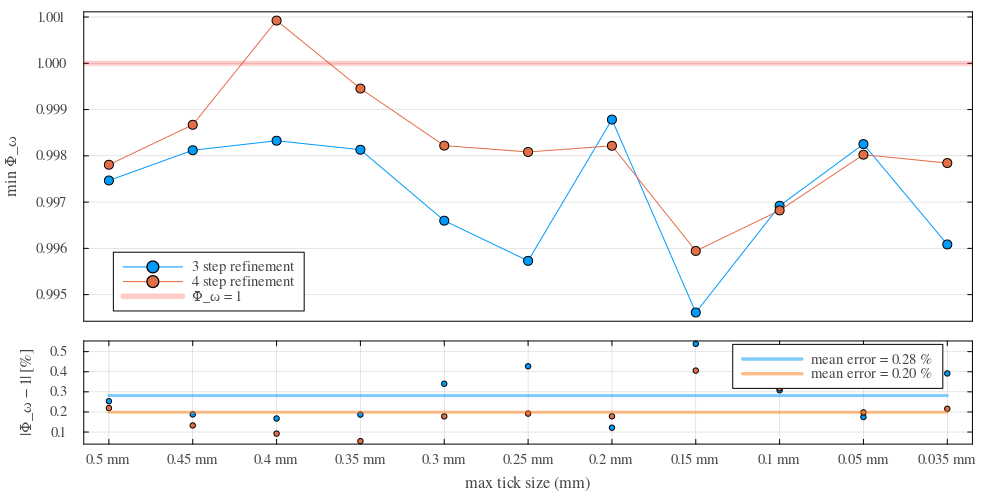

In [45]:
default(
    fontfamily = "Times",
    guidefontsize = 10,
    tickfontsize = 9,
    legendfontsize = 9,
    titlefontsize = 10,
    lw = 1,
    ms = 5
)

x = 1:length(grid_3ref)
labels = string.(grid_3ref)



# Plot superiore
p1 = plot(
    x, wp_min_3ref;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    xticks = false,
    lw = 1,
    ylabel = "min Φ_ω",
    legend = true,
    label = "3 step refinement",
framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

plot!(x, min_pot_4step, seriestype = :path,
    marker = :circle,
    markersize = 5,
    lw = 1,
    label = "4 step refinement"  )

hline!([1.0], linecolor = :red, lw =5 , alpha = 0.2, label = "Φ_ω = 1")

p2 = scatter(
    x,
    abs.(var_pct_3s),
    ylabel = "|Φ_ω − 1| [%]",
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = true,
    label = "",
    markersize = 3,
    top_margin = 0mm,
    bottom_margin = 5mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)
scatter!(x, abs.(var_pct_4s),
    markersize = 3, label ="",
    )


using Printf

mean_val = mean(abs.(var_pct_3s))
mean_val_str = @sprintf("%.2f", mean_val)   # 2 cifre decimali
plot!([x[1], x[end]], [mean_val, mean_val];
      lw=3, alpha=0.5, color="#009BFA",
      label = "mean error = $mean_val_str %")

mean_val4S = mean(abs.(var_pct_4s))
mean_val4S_str = @sprintf("%.2f", mean_val4S)
plot!([x[1], x[end]], [mean_val4S, mean_val4S];
      lw=3, alpha=0.5, color="#FD7E14",
      label = "mean error = $mean_val4S_str %")

plot(
    p1,
    p2,
    layout = grid(
        2, 1,
        heights = [0.75, 0.25],
        hspace = 0mm
    ),
    link = :x, size = (1000, 500)
)

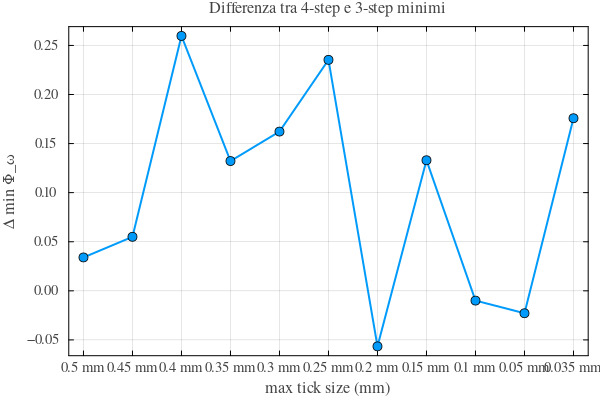

In [49]:
delta_pot = 100 .*(min_pot_4step .- wp_min_3ref)

# X asse: i punti principali della griglia (escludendo il gold)
x_main = 1:length(grid_3ref)   # come prima, le linee principali

# Plot della differenza
plot(
    x_main, delta_pot;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    lw = 2,
    xlabel = "max tick size (mm)",
    xticks = (x_main, string.(grid_3ref[x_main])),
    ylabel = "Δ min Φ_ω",
    title = "Differenza tra 4-step e 3-step minimi",
    grid = true,
    gridalpha = 0.1,
    legend = false,
    framestyle = :box
)

## Funzione totale


nella scrittura della funzione 'globale' vi sono dei parametri che sono più ottimizzati di quelli che uso io nella funzione a "pezzi". Questo potrebbe portare ad un miglioramento del minimo (anched dell'ordine di 1x1000)

In [1]:
grid_fin = [0.5u"mm"]
wp_min_fin = [0.99847]

LoadError: LoadError: UndefVarError: `@u_str` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
in expression starting at /home/ritaferi/Phd/SSDdev/notebooks/new_refinement_on_grid/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X22sdnNjb2RlLXJlbW90ZQ==.jl:1